In [1]:
from bs4 import BeautifulSoup
# import pandas as pd
from datetime import datetime, timedelta
from itertools import combinations
import json
import requests
import math
from typing import Optional, List, Dict
import os

from pydantic import BaseModel
from typing import Mapping
import numpy as np
import polars as pl
import hvplot.polars
import pandas as pd
import altair as alt
import math

from shared.utils import formalize_data_with_str
from shared.random_rules import RandomRules

In [2]:
rr = RandomRules(
  TOTAL_NUMBERS = 50,
  CHOOSE = 6,
  MAX_PRIMES = 3,
  N_VALUES=["1", "2", "3"],
  # Rangos de valores de las bolillas
  MIN_B_VALUES = [1, 2, 3, 4, 5, 6],
  MAX_B_VALUES = [45, 46, 47, 48, 49, 50]
)

In [3]:
url = 'https://resultados.latinka.com.pe/i.do?m=historico&t=0&s=41'
response = requests.get(url)
soup = BeautifulSoup(response.text, 'html.parser')

tables = soup.select('table')
rows = tables[1].find_all('tr')

In [4]:
lst = []
post_str_b1 = None
post_str_b2 = None
post_str_b3 = None
post_str_b4 = None
post_str_b5 = None
post_str_blast = None
for row in rows:
  cols = [data.text.strip() for data in row.find_all('td')]
  
  id, bolillas_int, str_combo = formalize_data_with_str(bolillas_str=cols[2])
  cols.append(id)
  cols.append(bolillas_int)
  cols.extend([b for b in bolillas_int])
  cols.extend(str_combo)
  cols.append(post_str_b1)
  cols.append(post_str_b2)
  cols.append(post_str_b3)
  cols.append(post_str_b4)
  cols.append(post_str_b5)
  cols.append(post_str_blast)

  is_rare, reason = rr.is_rare_combination(bolillas_int, id)
  cols.append(is_rare)
  cols.append(reason)

  cols.append(rr.jumps_map(bolillas_int))
  cols.append(rr.unijump(bolillas_int))
  cols.append(rr.prime_counter(bolillas_int))
  cols.append(rr.evens_counter(bolillas_int))
  cols.append(rr.odds_counter(bolillas_int))

  jumps = rr.jumps(bolillas_int)
  cols.append(jumps[0])
  cols.append(jumps[1])
  cols.append(jumps[2])
  cols.append(jumps[3])
  cols.append(jumps[4])
  sum_jumps = sum(jumps)
  cols.append(sum(jumps))
  cols.append(sum([1 for j in jumps if j > 9]))
  cols.append(len(list(set(jumps))))
  cols.append(int(any([b == sum_jumps for b in bolillas_int])))
  
  lst.append(cols)

  post_str_b1 = str_combo[0]
  post_str_b2 = str_combo[1]
  post_str_b3 = str_combo[2]
  post_str_b4 = str_combo[3]
  post_str_b5 = str_combo[4]
  post_str_blast = str_combo[-1]

with open('./gn_tnk_v3.json', 'w') as file: 
  json.dump(lst, file)

dfRows = pl.DataFrame(
  lst,
  schema=[
    'fecha', 'sorteo', 'bolillas', 'yapa', 'adicionales', 'sorteo_extra',
    'id', 'combo', 'b1', 'b2', 'b3', 'b4', 'b5', 'b6',
    'str_b1', 'str_b2', 'str_b3', 'str_b4', 'str_b5', 'str_b6',
    'post_str_b1', 'post_str_b2', 'post_str_b3', 'post_str_b4', 'post_str_b5', 'post_str_blast',
    'is_rare_combination', 'reason',
    "jumps_map", "unijump",
    "primes_count", "evens_count", "odds_count",
    "j1", "j2", "j3", "j4", "j5", "jsum", "joor", "jdiff", "hjsum"
  ],
  schema_overrides={
    'combo': pl.Array(pl.UInt8, 6),
    'b1': pl.UInt8,
    'b2': pl.UInt8,
    'b3': pl.UInt8,
    'b4': pl.UInt8,
    'b5': pl.UInt8,
    'b6': pl.UInt8,
    'reason': pl.UInt8,

    'primes_count': pl.String,
    'evens_count': pl.String,
    'odds_count': pl.String,
    "j1": pl.String,
    "j2": pl.String,
    "j3": pl.String,
    "j4": pl.String,
    "j5": pl.String,
    "jsum": pl.String,
    "joor": pl.String,
    "jdiff": pl.String,
    "jsum": pl.String,
    "hjsum": pl.String
  },
  orient='row'
)

TOTAL_LINES = len(dfRows)
print(f'{TOTAL_LINES=}')
display(dfRows.head(10))
dfRows.write_parquet('dfrows_tnk.parquet')

TOTAL_LINES=2506


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""27/08/2025""","""1224""","""40 19 13 46 30 36""","""03""","""43 38""","""Promoción Sí o Sí""","""131930364046""","[13, 19, … 46]",13,19,30,36,40,46,"""13""","""19""","""30""","""36""","""40""","""46""",null,null,null,null,null,null,true,16,"""06_11_06_04_06""",-12,"""2""","""4""","""2""","""6""","""11""","""6""","""4""","""6""","""33""","""1""","""3""","""0"""
"""24/08/2025""","""1223""","""12 37 16 08 22 17""","""07""","""32 27""","""Promoción Sí o Sí""","""081216172237""","[8, 12, … 37]",8,12,16,17,22,37,"""08""","""12""","""16""","""17""","""22""","""37""","""13""","""19""","""30""","""36""","""40""","""46""",true,8,"""04_04_01_05_15""",-11,"""2""","""4""","""2""","""4""","""4""","""1""","""5""","""15""","""29""","""1""","""4""","""0"""
"""20/08/2025""","""1222""","""28 37 09 29 06 49""","""48""","""30""","""Promoción Sí o Sí""","""060928293749""","[6, 9, … 49]",6,9,28,29,37,49,"""06""","""09""","""28""","""29""","""37""","""49""","""08""","""12""","""16""","""17""","""22""","""37""",true,16,"""03_19_01_08_12""",-87,"""2""","""2""","""4""","""3""","""19""","""1""","""8""","""12""","""43""","""2""","""5""","""0"""
"""17/08/2025""","""1221""","""34 11 39 07 26 27""","""37""","""25 22""","""Promoción Sí o Sí""","""071126273439""","[7, 11, … 39]",7,11,26,27,34,39,"""07""","""11""","""26""","""27""","""34""","""39""","""06""","""09""","""28""","""29""","""37""","""49""",false,0,"""04_15_01_07_05""",-73,"""2""","""2""","""4""","""4""","""15""","""1""","""7""","""5""","""32""","""1""","""5""","""0"""
"""13/08/2025""","""1220""","""36 07 43 32 20 33""","""17""","""41 42""","""Promoción Sí o Sí""","""072032333643""","[7, 20, … 43]",7,20,32,33,36,43,"""07""","""20""","""32""","""33""","""36""","""43""","""07""","""11""","""26""","""27""","""34""","""39""",true,16,"""13_12_01_03_07""",-34,"""2""","""3""","""3""","""13""","""12""","""1""","""3""","""7""","""36""","""2""","""5""","""1"""
"""10/08/2025""","""1219""","""24 46 29 19 25 47""","""26""","""06 33 02""","""Promoción Sí o Sí""","""192425294647""","[19, 24, … 47]",19,24,25,29,46,47,"""19""","""24""","""25""","""29""","""46""","""47""","""07""","""20""","""32""","""33""","""36""","""43""",true,16,"""05_01_04_17_01""",-42,"""3""","""2""","""4""","""5""","""1""","""4""","""17""","""1""","""28""","""1""","""4""","""0"""
"""06/08/2025""","""1218""","""38 23 06 21 33 36""","""16""","""49 07""","""Promoción Sí o Sí""","""062123333638""","[6, 21, … 38]",6,21,23,33,36,38,"""06""","""21""","""23""","""33""","""36""","""38""","""19""","""24""","""25""","""29""","""46""","""47""",false,0,"""15_02_10_03_02""",57,"""1""","""3""","""3""","""15""","""2""","""10""","""3""","""2""","""32""","""2""","""4""","""0"""
"""03/08/2025""","""1217""","""45 41 02 14 23 46""","""22""","""05 39""","""Promoción Sí o Sí""","""021423414546""","[2, 14, … 46]",2,14,23,41,45,46,"""02""","""14""","""23""","""41""","""45""","""46""","""06""","""21""","""23""","""33""","""36""","""38""",false,0,"""12_09_18_04_01""",69,"""3""","""3""","""3""","""12""","""9""","""18""","""4""","""1""","""44""","""2""","""5""","""0"""
"""30/07/2025""","""1216""","""43 28 03 09 01 25""","""23""","""31""","""Promoción Sí o Sí""","""010309252843""","[1, 3, … 43]",1,3,9,25,28,43,"""01""","""03""","""09""","""25""","""28""","""43""","""02""","""14""","""23""","""41""","""45""","""46""",false,0,"""02_06_16_03_15""",77,"""2""","""1""","""5""","""2""","""6""","""16""","""3""","""15""","""42""","""2""","""5""","""0"""


In [5]:
dfRows.filter(
  pl.col("b1") > 10
)

fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""27/08/2025""","""1224""","""40 19 13 46 30 36""","""03""","""43 38""","""Promoción Sí o Sí""","""131930364046""","[13, 19, … 46]",13,19,30,36,40,46,"""13""","""19""","""30""","""36""","""40""","""46""",null,null,null,null,null,null,true,16,"""06_11_06_04_06""",-12,"""2""","""4""","""2""","""6""","""11""","""6""","""4""","""6""","""33""","""1""","""3""","""0"""
"""10/08/2025""","""1219""","""24 46 29 19 25 47""","""26""","""06 33 02""","""Promoción Sí o Sí""","""192425294647""","[19, 24, … 47]",19,24,25,29,46,47,"""19""","""24""","""25""","""29""","""46""","""47""","""07""","""20""","""32""","""33""","""36""","""43""",true,16,"""05_01_04_17_01""",-42,"""3""","""2""","""4""","""5""","""1""","""4""","""17""","""1""","""28""","""1""","""4""","""0"""
"""29/06/2025""","""1207""","""47 37 32 22 24 23""","""04""","""20 39 09""","""Promoción Sí o Sí""","""222324323747""","[22, 23, … 47]",22,23,24,32,37,47,"""22""","""23""","""24""","""32""","""37""","""47""","""07""","""10""","""14""","""28""","""29""","""32""",true,24,"""01_01_08_05_10""",35,"""3""","""3""","""3""","""1""","""1""","""8""","""5""","""10""","""25""","""1""","""4""","""0"""
"""15/06/2025""","""1203""","""41 24 42 34 29 44""","""26""","""08 30 39""","""Promoción Sí o Sí""","""242934414244""","[24, 29, … 44]",24,29,34,41,42,44,"""24""","""29""","""34""","""41""","""42""","""44""","""09""","""24""","""26""","""28""","""45""","""50""",true,8,"""05_05_07_01_02""",25,"""2""","""4""","""2""","""5""","""5""","""7""","""1""","""2""","""20""","""0""","""4""","""0"""
"""11/06/2025""","""1202""","""22 39 20 19 38 15""","""32""","""13 35 25""","""Promoción Sí o Sí""","""151920223839""","[15, 19, … 39]",15,19,20,22,38,39,"""15""","""19""","""20""","""22""","""38""","""39""","""24""","""29""","""34""","""41""","""42""","""44""",false,0,"""04_01_02_16_01""",-51,"""1""","""3""","""3""","""4""","""1""","""2""","""16""","""1""","""24""","""1""","""4""","""0"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""10/09/1995""","""0048""","""11 19 20 21 24 36""","""""","""""","""""","""111920212436""","[11, 19, … 36]",11,19,20,21,24,36,"""11""","""19""","""20""","""21""","""24""","""36""","""10""","""13""","""17""","""21""","""23""","""32""",true,8,"""08_01_01_03_12""",10,"""2""","""3""","""3""","""8""","""1""","""1""","""3""","""12""","""25""","""1""","""4""","""0"""
"""23/07/1995""","""0041""","""14 18 21 25 29 30""","""""","""""","""""","""141821252930""","[14, 18, … 30]",14,18,21,25,29,30,"""14""","""18""","""21""","""25""","""29""","""30""","""03""","""04""","""06""","""10""","""16""","""29""",true,8,"""04_03_04_04_01""",1,"""1""","""3""","""3""","""4""","""3""","""4""","""4""","""1""","""16""","""0""","""3""","""0"""
"""09/04/1995""","""0026""","""16 18 24 25 29 31""","""""","""""","""""","""161824252931""","[16, 18, … 31]",16,18,24,25,29,31,"""16""","""18""","""24""","""25""","""29""","""31""","""01""","""03""","""19""","""27""","""30""","""35""",false,0,"""02_06_01_04_02""",-30,"""2""","""3""","""3""","""2""","""6""","""1""","""4""","""2""","""15""","""0""","""4""","""0"""


In [6]:

def count_column (df: pl.DataFrame, col_name: str, k: int = None) -> None:
  df_viz = (df if k == None else df[0:k]) \
    .group_by(
      col_name
    ).agg(pl.count(col_name).alias('count')) \
    .sort("count", descending=True)

  chart = df_viz.hvplot.bar(
    x=col_name,
    y='count'
  )

  chart.opts(default_tools=["pan"])
  display(chart)
  return df_viz[col_name].to_list()

jjsum = count_column(dfRows, 'hjsum', 100)
jdiff_count = count_column(dfRows, 'jdiff', 100)

j1_count = count_column(dfRows, 'j1', 100)
j2_count = count_column(dfRows, 'j2', 100)
j3_count = count_column(dfRows, 'j3', 100)
j4_count = count_column(dfRows, 'j4', 100)
j5_count = count_column(dfRows, 'j5', 100)

joor_count = count_column(dfRows, "joor", 100)
primes_count = count_column(dfRows, 'primes_count', 100)
evens_count = count_column(dfRows, 'evens_count', 100)
odds_count = count_column(dfRows, 'odds_count', 100)

jsums = count_column(dfRows, 'jsum', 100)
# print(jsums[0:22])



:Bars   [hjsum]   (count)

:Bars   [jdiff]   (count)

:Bars   [j1]   (count)

:Bars   [j2]   (count)

:Bars   [j3]   (count)

...

:Bars   [joor]   (count)

:Bars   [primes_count]   (count)

:Bars   [evens_count]   (count)

:Bars   [odds_count]   (count)

:Bars   [jsum]   (count)

In [7]:
dfRows.item(0, 'b2')

19

In [8]:
import holoviews as hv
def plot_post_col (col: str, post_col: str, test_value: str | None = None):
  if test_value == None:
    test_value = dfRows.item(0, col)
    print(f'Setting {test_value=}')

  df_viz = dfRows \
    .filter(
      pl.col(col) == test_value,
      pl.col(post_col).is_not_null()
    ) \
    .group_by(
      post_col
    ).agg(pl.count(post_col).alias('count')) \
    .sort("count", descending=True)
  
  
  df_10_last = dfRows \
    .filter(
      pl.col(col) == test_value,
      pl.col(post_col).is_not_null()
    ) \
    .head(10)
  
  # Agrega una columna que sea el porcentaje de la frecuencia relativa
  total = df_viz['count'].sum()
  df_viz = df_viz.with_columns(
    ( (pl.col('count') / total) * 100 ).alias('percent')
  )

  mean_percent = df_viz['percent'].mean()
  mean_percent_75 = mean_percent * 75 / 50
  mean_percent_25 = mean_percent * 25 / 50

  chart = df_viz.hvplot.bar(
    x=post_col,
    y='percent'
  )

  chart = chart * hv.HLine(mean_percent).opts(color='red')
  chart = chart * hv.HLine(mean_percent_75).opts(color='blue')
  chart = chart * hv.HLine(mean_percent_25).opts(color='blue')
  
  chart.opts(default_tools=["pan"])

  df_jumps_map = dfRows \
    .filter(
      pl.col(col) == test_value,
      pl.col(post_col).is_not_null()
    ) \
    .group_by(
      'jumps_map'
    ).agg(pl.count('jumps_map').alias('count')) \
    .sort("count", descending=True)
  
  df_unijump = dfRows \
    .filter(
      pl.col(col) == test_value,
      pl.col(post_col).is_not_null()
    ) \
    .group_by(
      'unijump'
    ).agg(pl.count('unijump').alias('count')) \
    .sort("count", descending=True)


  print(f'df_viz FOR {col} = {test_value}')
  display(df_viz)

  display(chart)
  

  print(f'df_10_last FOR {col} = {test_value}')
  last_results = list(set(df_10_last[post_col][0:3]))
  print(f'Last 3 results {last_results=}')
  display(df_10_last)
  
  print(f'df_jumps_map FOR {col} = {test_value}')
  display(df_jumps_map)
  # display(df_unijump)

  print(f'df_unijump FOR {col} = {test_value}')
  display(df_unijump)

  lst_post_str_b = df_viz.filter(pl.col('percent') >= mean_percent)[post_col].to_list()
  lst_jumps_map = df_jumps_map['jumps_map'].to_list() # Used to discard
  
  return lst_post_str_b, lst_jumps_map, last_results

In [9]:
possible_b1, exclude_jump_maps_b1, last_post_b1 = plot_post_col(col='str_b1', post_col='post_str_b1')

Setting test_value='13'
df_viz FOR str_b1 = 13


post_str_b1,count,percent
str,u32,f64
"""01""",20,26.315789
"""02""",9,11.842105
"""03""",5,6.578947
"""11""",5,6.578947
"""07""",4,5.263158
…,…,…
"""21""",1,1.315789
"""18""",1,1.315789
"""20""",1,1.315789


:Overlay
   .Bars.I    :Bars   [post_str_b1]   (percent)
   .HLine.I   :HLine   [x,y]
   .HLine.II  :HLine   [x,y]
   .HLine.III :HLine   [x,y]

df_10_last FOR str_b1 = 13
Last 3 results last_results=['02', '20', '12']


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""26/01/2025""","""1163""","""33 26 35 30 13 18""","""05""","""27 10""","""Promoción Sí o Sí""","""131826303335""","[13, 18, … 35]",13,18,26,30,33,35,"""13""","""18""","""26""","""30""","""33""","""35""","""12""","""13""","""17""","""23""","""24""","""33""",false,0,"""05_08_04_03_02""",-13,"""1""","""3""","""3""","""5""","""8""","""4""","""3""","""2""","""22""","""0""","""5""","""0"""
"""05/01/2025""","""1157""","""18 49 45 13 35 22""","""21""","""19 07 36 08""","""Promoción Sí o Sí""","""131822354549""","[13, 18, … 49]",13,18,22,35,45,49,"""13""","""18""","""22""","""35""","""45""","""49""","""20""","""24""","""25""","""40""","""44""","""47""",false,0,"""05_04_13_10_04""",31,"""1""","""2""","""4""","""5""","""4""","""13""","""10""","""4""","""36""","""2""","""4""","""0"""
"""02/10/2024""","""1130""","""47 50 20 13 43 17""","""33""","""42 16 45 08""","""Promoción Sí o Sí""","""131720434750""","[13, 17, … 50]",13,17,20,43,47,50,"""13""","""17""","""20""","""43""","""47""","""50""","""02""","""06""","""08""","""09""","""14""","""25""",true,1,"""04_03_23_04_03""",117,"""4""","""2""","""4""","""4""","""3""","""23""","""4""","""3""","""37""","""1""","""3""","""0"""
"""30/06/2024""","""1103""","""48 38 15 42 13 34""","""11""","""44 41 12 10""","""Promoción Sí o Sí""","""131534384248""","[13, 15, … 48]",13,15,34,38,42,48,"""13""","""15""","""34""","""38""","""42""","""48""","""01""","""06""","""14""","""22""","""24""","""34""",true,8,"""02_19_04_04_06""",-60,"""1""","""4""","""2""","""2""","""19""","""4""","""4""","""6""","""35""","""1""","""4""","""0"""
"""19/05/2024""","""1091""","""13 18 44 15 21 38""","""43""","""28 27 06 11""","""Promoción Sí o Sí""","""131518213844""","[13, 15, … 44]",13,15,18,21,38,44,"""13""","""15""","""18""","""21""","""38""","""44""","""15""","""21""","""31""","""33""","""39""","""47""",true,8,"""02_03_03_17_06""",-54,"""1""","""3""","""3""","""2""","""3""","""3""","""17""","""6""","""31""","""1""","""4""","""0"""
"""17/03/2024""","""1073""","""17 19 13 41 34 24""","""26""","""18 22""","""Promoción Sí o Sí""","""131719243441""","[13, 17, … 41]",13,17,19,24,34,41,"""13""","""17""","""19""","""24""","""34""","""41""","""08""","""10""","""11""","""21""","""22""","""31""",true,1,"""04_02_05_10_07""",-7,"""4""","""2""","""4""","""4""","""2""","""5""","""10""","""7""","""28""","""1""","""5""","""0"""
"""28/02/2024""","""1068""","""42 13 30 27 45 14""","""08""","""15 03""","""Promoción Sí o Sí""","""131427304245""","[13, 14, … 45]",13,14,27,30,42,45,"""13""","""14""","""27""","""30""","""42""","""45""","""06""","""25""","""27""","""31""","""33""","""48""",false,0,"""01_13_03_12_03""",-78,"""1""","""3""","""3""","""1""","""13""","""3""","""12""","""3""","""32""","""2""","""4""","""0"""
"""15/10/2023""","""1029""","""13 42 41 44 36 20""","""12""","""18 19 09""","""Promoción Sí o Sí""","""132036414244""","[13, 20, … 44]",13,20,36,41,42,44,"""13""","""20""","""36""","""41""","""42""","""44""","""11""","""27""","""35""","""40""","""44""","""45""",false,0,"""07_16_05_01_02""",-29,"""2""","""4""","""2""","""7""","""16""","""5""","""1""","""2""","""31""","""1""","""5""","""0"""
"""26/07/2023""","""1006""","""13 17 26 24 15 39""","""22""","""07 29""","""Promoción Sí o Sí""","""131517242639""","[13, 15, … 39]",13,15,17,24,26,39,"""13""","""15""","""17""","""24""","""26""","""39""","""18""","""21""","""27""","""39""","""40""","""44""",true,8,"""02_02_07_02_13""",41,"""2""","""2""","""4""","""2""","""2""","""7""","""2""","""13""","""26""","""1"""

df_jumps_map FOR str_b1 = 13


jumps_map,count
str,u32
"""02_02_07_02_13""",1
"""02_01_04_03_14""",1
"""02_01_06_12_06""",1
"""02_04_01_03_11""",1
"""07_01_02_06_04""",1
…,…
"""05_01_04_03_01""",1
"""10_01_05_04_01""",1
"""14_02_02_07_02""",1


df_unijump FOR str_b1 = 13


unijump,count
i64,u32
17,3
-31,2
-24,2
-9,2
7,2
…,…
117,1
27,1
32,1


In [10]:
possible_b2, exclude_jump_maps_b2, last_post_b2 = plot_post_col(col='str_b2', post_col='post_str_b2')

Setting test_value='19'
df_viz FOR str_b2 = 19


post_str_b2,count,percent
str,u32,f64
"""09""",10,10.752688
"""07""",8,8.602151
"""14""",8,8.602151
"""10""",8,8.602151
"""13""",6,6.451613
…,…,…
"""28""",1,1.075269
"""31""",1,1.075269
"""23""",1,1.075269


:Overlay
   .Bars.I    :Bars   [post_str_b2]   (percent)
   .HLine.I   :HLine   [x,y]
   .HLine.II  :HLine   [x,y]
   .HLine.III :HLine   [x,y]

df_10_last FOR str_b2 = 19
Last 3 results last_results=['08', '29', '12']


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""11/06/2025""","""1202""","""22 39 20 19 38 15""","""32""","""13 35 25""","""Promoción Sí o Sí""","""151920223839""","[15, 19, … 39]",15,19,20,22,38,39,"""15""","""19""","""20""","""22""","""38""","""39""","""24""","""29""","""34""","""41""","""42""","""44""",false,0,"""04_01_02_16_01""",-51,"""1""","""3""","""3""","""4""","""1""","""2""","""16""","""1""","""24""","""1""","""4""","""0"""
"""19/02/2025""","""1170""","""44 02 19 47 29 31""","""21""","""32 14 35""","""Promoción Sí o Sí""","""021929314447""","[2, 19, … 47]",2,19,29,31,44,47,"""02""","""19""","""29""","""31""","""44""","""47""","""05""","""08""","""10""","""30""","""36""","""44""",true,1,"""17_10_02_13_03""",-60,"""5""","""2""","""4""","""17""","""10""","""2""","""13""","""3""","""45""","""3""","""5""","""0"""
"""05/02/2025""","""1166""","""19 12 27 33 24 30""","""17""","""07""","""Promoción Sí o Sí""","""121924273033""","[12, 19, … 33]",12,19,24,27,30,33,"""12""","""19""","""24""","""27""","""30""","""33""","""03""","""12""","""33""","""34""","""35""","""46""",true,8,"""07_05_03_03_03""",-4,"""1""","""3""","""3""","""7""","""5""","""3""","""3""","""3""","""21""","""0""","""3""","""0"""
"""15/01/2025""","""1160""","""36 16 47 38 19 46""","""32""","""18 24 43 08""","""Promoción Sí o Sí""","""161936384647""","[16, 19, … 47]",16,19,36,38,46,47,"""16""","""19""","""36""","""38""","""46""","""47""","""01""","""02""","""05""","""23""","""44""","""45""",true,16,"""03_17_02_08_01""",-84,"""2""","""4""","""2""","""3""","""17""","""2""","""8""","""1""","""31""","""1""","""5""","""0"""
"""24/11/2024""","""1145""","""46 05 45 19 29 26""","""18""","""03 25""","""Promoción Sí o Sí""","""051926294546""","[5, 19, … 46]",5,19,26,29,45,46,"""05""","""19""","""26""","""29""","""45""","""46""","""05""","""09""","""13""","""17""","""23""","""34""",true,16,"""14_07_03_16_01""",-59,"""3""","""2""","""4""","""14""","""7""","""3""","""16""","""1""","""41""","""2""","""5""","""0"""
"""01/09/2024""","""1121""","""23 50 41 19 04 37""","""28""","""09 06""","""Promoción Sí o Sí""","""041923374150""","[4, 19, … 50]",4,19,23,37,41,50,"""04""","""19""","""23""","""37""","""41""","""50""","""04""","""09""","""15""","""30""","""40""","""50""",true,1,"""15_04_14_04_09""",76,"""4""","""2""","""4""","""15""","""4""","""14""","""4""","""9""","""46""","""2""","""4""","""0"""
"""17/07/2024""","""1108""","""40 47 01 43 19 38""","""16""","""05 17 35 32""","""Promoción Sí o Sí""","""011938404347""","[1, 19, … 47]",1,19,38,40,43,47,"""01""","""19""","""38""","""40""","""43""","""47""","""11""","""25""","""26""","""30""","""39""","""47""",true,16,"""18_19_02_03_04""",-54,"""3""","""2""","""4""","""18""","""19""","""2""","""3""","""4""","""46""","""2""","""5""","""0"""
"""01/05/2024""","""1086""","""25 30 15 26 19 44""","""21""","""42 02""","""Promoción Sí o Sí""","""151925263044""","[15, 19, … 44]",15,19,25,26,30,44,"""15""","""19""","""25""","""26""","""30""","""44""","""05""","""09""","""25""","""36""","""38""","""45""",false,0,"""04_06_01_04_14""",-16,"""1""","""3""","""3""","""4""","""6""","""1""","""4""","""14""","""29""","""1""","""4""","""0"""
"""27/12/2023""","""1050""","""45 09 19 26 47 25""","""44""","""41 27 46""","""Promoción Sí o Sí""","""091925264547""","[9, 19, … 47]",9,19,25,26,45,47,"""09""","""19""","""25""","""26""","""45""","""47""","""09""","""15""","""23""","""27""","""28""","""35""",true,16,"""10_06_01_19_02""",-82,"""2""","""1""","""5""","""10""","""6""","""1""","""19""","""2""","""38""","""2""","""5""","""

df_jumps_map FOR str_b2 = 19


jumps_map,count
str,u32
"""07_01_03_02_16""",1
"""03_01_01_07_15""",1
"""12_05_04_01_05""",1
"""04_10_02_02_01""",1
"""05_01_13_02_09""",1
…,…
"""07_05_03_03_03""",1
"""12_05_04_04_11""",1
"""18_01_09_03_11""",1


df_unijump FOR str_b2 = 19


unijump,count
i64,u32
-8,3
-7,3
-41,3
-4,3
11,3
…,…
-28,1
-63,1
21,1


In [11]:
possible_b3, exclude_jump_maps_b3, last_post_b3 = plot_post_col(col='str_b3', post_col='post_str_b3')

Setting test_value='30'
df_viz FOR str_b3 = 30


post_str_b3,count,percent
str,u32,f64
"""21""",6,11.111111
"""17""",5,9.259259
"""34""",4,7.407407
"""18""",4,7.407407
"""26""",4,7.407407
…,…,…
"""33""",1,1.851852
"""10""",1,1.851852
"""23""",1,1.851852


:Overlay
   .Bars.I    :Bars   [post_str_b3]   (percent)
   .HLine.I   :HLine   [x,y]
   .HLine.II  :HLine   [x,y]
   .HLine.III :HLine   [x,y]

df_10_last FOR str_b3 = 30
Last 3 results last_results=['09', '28', '34']


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""23/06/2024""","""1101""","""30 41 11 05 36 35""","""15""","""44 26""","""Promoción Sí o Sí""","""051130353641""","[5, 11, … 41]",5,11,30,35,36,41,"""05""","""11""","""30""","""35""","""36""","""41""","""01""","""06""","""09""","""11""","""14""","""43""",true,16,"""06_19_05_01_05""",-39,"""3""","""2""","""4""","""6""","""19""","""5""","""1""","""5""","""36""","""1""","""4""","""1"""
"""10/03/2024""","""1071""","""35 34 18 32 12 30""","""24""","""07 04 19""","""Promoción Sí o Sí""","""121830323435""","[12, 18, … 35]",12,18,30,32,34,35,"""12""","""18""","""30""","""32""","""34""","""35""","""16""","""18""","""34""","""43""","""46""","""48""",true,8,"""06_12_02_02_01""",-37,"""0""","""5""","""1""","""6""","""12""","""2""","""2""","""1""","""23""","""1""","""4""","""0"""
"""28/09/2022""","""0920""","""38 14 30 36 31 29""","""40""","""04 44 22 27""","""Promoción Sí o Sí""","""142930313638""","[14, 29, … 38]",14,29,30,31,36,38,"""14""","""29""","""30""","""31""","""36""","""38""","""09""","""24""","""28""","""32""","""37""","""44""",true,8,"""15_01_01_05_02""",-1,"""2""","""4""","""2""","""15""","""1""","""1""","""5""","""2""","""24""","""1""","""4""","""0"""
"""29/06/2022""","""0894""","""44 37 14 30 45 25""","""24""","""02""","""Promoción Sí o Sí""","""142530374445""","[14, 25, … 45]",14,25,30,37,44,45,"""14""","""25""","""30""","""37""","""44""","""45""","""04""","""15""","""17""","""26""","""31""","""38""",true,8,"""11_05_07_07_01""",6,"""1""","""3""","""3""","""11""","""5""","""7""","""7""","""1""","""31""","""1""","""4""","""0"""
"""26/01/2022""","""0850""","""11 26 43 40 33 30""","""21""","""""","""""","""112630334043""","[11, 26, … 43]",11,26,30,33,40,43,"""11""","""26""","""30""","""33""","""40""","""43""","""04""","""05""","""15""","""21""","""35""","""36""",false,0,"""15_04_03_07_03""",-8,"""2""","""3""","""3""","""15""","""4""","""3""","""7""","""3""","""32""","""1""","""4""","""0"""
"""25/04/2021""","""0771""","""33 26 41 23 39 30""","""02""","""""","""""","""232630333941""","[23, 26, … 41]",23,26,30,33,39,41,"""23""","""26""","""30""","""33""","""39""","""41""","""09""","""21""","""34""","""38""","""39""","""42""",false,0,"""03_04_03_06_02""",-17,"""2""","""2""","""4""","""3""","""4""","""3""","""6""","""2""","""18""","""0""","""4""","""0"""
"""17/02/2021""","""0752""","""37 15 45 33 11 30""","""05""","""""","""""","""111530333745""","[11, 15, … 45]",11,15,30,33,37,45,"""11""","""15""","""30""","""33""","""37""","""45""","""14""","""15""","""17""","""28""","""41""","""44""",true,16,"""04_15_03_04_08""",-46,"""2""","""1""","""5""","""4""","""15""","""3""","""4""","""8""","""34""","""1""","""4""","""0"""
"""15/05/2019""","""0601""","""31 29 30 38 40 01""","""32""","""""","""""","""012930313840""","[1, 29, … 40]",1,29,30,31,38,40,"""01""","""29""","""30""","""31""","""38""","""40""","""02""","""03""","""04""","""13""","""19""","""20""",true,8,"""28_01_01_07_02""",4,"""2""","""3""","""3""","""28""","""1""","""1""","""7""","""2""","""39""","""1""","""4""","""0"""
"""13/02/2019""","""0575""","""13 05 35 33 40 30""","""32""","""""","""""","""051330333540""","[5, 13, … 40]",5,13,30,33,35,40,"""05""","""13""","""30""","""33""","""35""","""40""","""10""","""25""","""28""","""31""","""40""","""42""",true,16,"""08_17_03_02_05""",-45,"""2""","""2""","""4""","""8""","""17""","""3""","""2""","""5""","""35""","""1""","""5""","""1"""


df_jumps_map FOR str_b3 = 30


jumps_map,count
str,u32
"""15_01_07_03_05""",1
"""17_11_05_02_08""",1
"""04_15_03_04_08""",1
"""13_14_02_07_05""",1
"""07_01_05_05_03""",1
…,…
"""09_06_04_01_02""",1
"""01_05_06_01_03""",1
"""03_09_06_05_04""",1


df_unijump FOR str_b3 = 30


unijump,count
i64,u32
7,3
-1,3
-54,3
20,2
16,2
…,…
-45,1
23,1
44,1


In [12]:
possible_b4, exclude_jump_maps_b4, last_post_b4 = plot_post_col(col='str_b4', post_col='post_str_b4')

Setting test_value='36'
df_viz FOR str_b4 = 36


post_str_b4,count,percent
str,u32,f64
"""23""",8,9.411765
"""27""",8,9.411765
"""22""",7,8.235294
"""35""",6,7.058824
"""28""",5,5.882353
…,…,…
"""39""",1,1.176471
"""20""",1,1.176471
"""17""",1,1.176471


:Overlay
   .Bars.I    :Bars   [post_str_b4]   (percent)
   .HLine.I   :HLine   [x,y]
   .HLine.II  :HLine   [x,y]
   .HLine.III :HLine   [x,y]

df_10_last FOR str_b4 = 36
Last 3 results last_results=['27', '37', '32']


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""15/09/2024""","""1125""","""36 43 29 01 03 38""","""25""","""19 18 35 02""","""Promoción Sí o Sí""","""010329363843""","[1, 3, … 43]",1,3,29,36,38,43,"""01""","""03""","""29""","""36""","""38""","""43""","""10""","""21""","""26""","""32""","""34""","""37""",false,0,"""02_26_07_02_05""",-63,"""3""","""2""","""4""","""2""","""26""","""7""","""2""","""5""","""42""","""1""","""4""","""0"""
"""25/08/2024""","""1119""","""49 01 42 14 27 36""","""05""","""21 45""","""Promoción Sí o Sí""","""011427364249""","[1, 14, … 49]",1,14,27,36,42,49,"""01""","""14""","""27""","""36""","""42""","""49""","""03""","""06""","""11""","""37""","""46""","""47""",true,8,"""13_13_09_06_07""",-2,"""0""","""3""","""3""","""13""","""13""","""9""","""6""","""7""","""48""","""2""","""4""","""0"""
"""05/05/2024""","""1087""","""45 36 09 25 38 05""","""37""","""01 20 10""","""Promoción Sí o Sí""","""050925363845""","[5, 9, … 45]",5,9,25,36,38,45,"""05""","""09""","""25""","""36""","""38""","""45""","""01""","""04""","""20""","""27""","""45""","""47""",true,16,"""04_16_11_02_07""",5,"""1""","""2""","""4""","""4""","""16""","""11""","""2""","""7""","""40""","""2""","""5""","""0"""
"""28/04/2024""","""1085""","""25 36 41 43 06 22""","""20""","""""","""""","""062225364143""","[6, 22, … 43]",6,22,25,36,41,43,"""06""","""22""","""25""","""36""","""41""","""43""","""15""","""19""","""25""","""26""","""30""","""44""",false,0,"""16_03_11_05_02""",52,"""2""","""3""","""3""","""16""","""3""","""11""","""5""","""2""","""37""","""2""","""5""","""0"""
"""17/09/2023""","""1021""","""36 05 47 46 07 08""","""14""","""02 01 18""","""Promoción Sí o Sí""","""050708364647""","[5, 7, … 47]",5,7,8,36,46,47,"""05""","""07""","""08""","""36""","""46""","""47""","""19""","""24""","""27""","""34""","""42""","""47""",true,16,"""02_01_28_10_01""",127,"""3""","""3""","""3""","""2""","""1""","""28""","""10""","""1""","""42""","""2""","""4""","""0"""
"""12/02/2023""","""0959""","""45 25 35 42 03 36""","""27""","""26 37 41 40""","""Promoción Sí o Sí""","""032535364245""","[3, 25, … 45]",3,25,35,36,42,45,"""03""","""25""","""35""","""36""","""42""","""45""","""28""","""31""","""34""","""38""","""44""","""45""",true,16,"""22_10_01_06_03""",-33,"""1""","""2""","""4""","""22""","""10""","""1""","""6""","""3""","""42""","""2""","""5""","""1"""
"""27/11/2022""","""0937""","""37 36 20 01 11 38""","""35""","""16 39 27""","""Promoción Sí o Sí""","""011120363738""","[1, 11, … 38]",1,11,20,36,37,38,"""01""","""11""","""20""","""36""","""37""","""38""","""01""","""05""","""09""","""17""","""33""","""41""",true,8,"""10_09_16_01_01""",67,"""2""","""3""","""3""","""10""","""9""","""16""","""1""","""1""","""37""","""2""","""4""","""1"""
"""13/04/2022""","""0872""","""36 04 25 08 46 45""","""38""","""09 21""","""Promoción Sí o Sí""","""040825364546""","[4, 8, … 46]",4,8,25,36,45,46,"""04""","""08""","""25""","""36""","""45""","""46""","""02""","""04""","""12""","""37""","""44""","""46""",true,16,"""04_17_11_09_01""",-33,"""0""","""4""","""2""","""4""","""17""","""11""","""9""","""1""","""42""","""2""","""5""","""0"""
"""16/02/2022""","""0856""","""04 25 44 36 16 40""","""43""","""02 17 11 20""","""Promoción Sí o Sí""","""041625364044""","[4, 16, … 44]",4,16,25,36,40,44,"""04""","""16""","""25""","""36""","""40""","""44""","""05""","""11""","""24""","""28""","""38""","""46""",true,8,"""12_09_11_04_04""",30,"""0""","""5""","""1""","""12""","""9""","""11""","""4""","""4""","""40""","""2""","""4""","""1"""


df_jumps_map FOR str_b4 = 36


jumps_map,count
str,u32
"""02_14_18_06_03""",1
"""02_01_08_08_01""",1
"""24_06_01_02_07""",1
"""08_04_22_01_07""",1
"""15_05_11_05_04""",1
…,…
"""16_03_11_05_02""",1
"""10_16_02_01_01""",1
"""02_26_07_02_05""",1


df_unijump FOR str_b4 = 36


unijump,count
i64,u32
5,4
1,3
-33,3
127,2
-67,2
…,…
128,1
-71,1
-73,1


In [13]:
possible_b5, exclude_jump_maps_b5, last_post_b5 = plot_post_col(col='str_b5', post_col='post_str_b5')

Setting test_value='40'
df_viz FOR str_b5 = 40


post_str_b5,count,percent
str,u32,f64
"""40""",8,6.61157
"""36""",7,5.785124
"""34""",7,5.785124
"""38""",7,5.785124
"""41""",7,5.785124
…,…,…
"""46""",1,0.826446
"""12""",1,0.826446
"""17""",1,0.826446


:Overlay
   .Bars.I    :Bars   [post_str_b5]   (percent)
   .HLine.I   :HLine   [x,y]
   .HLine.II  :HLine   [x,y]
   .HLine.III :HLine   [x,y]

df_10_last FOR str_b5 = 40
Last 3 results last_results=['42', '32', '24']


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""02/04/2025""","""1182""","""46 10 23 31 40 22""","""50""","""03 13 25""","""Promoción Sí o Sí""","""102223314046""","[10, 22, … 46]",10,22,23,31,40,46,"""10""","""22""","""23""","""31""","""40""","""46""","""05""","""16""","""27""","""34""","""42""","""49""",false,0,"""12_01_08_09_06""",26,"""2""","""4""","""2""","""12""","""1""","""8""","""9""","""6""","""36""","""1""","""5""","""0"""
"""22/12/2024""","""1153""","""17 02 49 40 24 01""","""45""","""14 22 05""","""Promoción Sí o Sí""","""010217244049""","[1, 2, … 49]",1,2,17,24,40,49,"""01""","""02""","""17""","""24""","""40""","""49""","""02""","""05""","""14""","""15""","""24""","""39""",true,16,"""01_15_07_16_09""",-72,"""2""","""3""","""3""","""1""","""15""","""7""","""16""","""9""","""48""","""2""","""5""","""0"""
"""23/10/2024""","""1136""","""28 09 16 01 46 40""","""50""","""37 41 27""","""Promoción Sí o Sí""","""010916284046""","[1, 9, … 46]",1,9,16,28,40,46,"""01""","""09""","""16""","""28""","""40""","""46""","""06""","""16""","""24""","""27""","""32""","""47""",true,24,"""08_07_12_12_06""",10,"""0""","""4""","""2""","""8""","""7""","""12""","""12""","""6""","""45""","""2""","""4""","""0"""
"""04/09/2024""","""1122""","""50 30 04 09 15 40""","""31""","""29 16 32""","""Promoción Sí o Sí""","""040915304050""","[4, 9, … 50]",4,9,15,30,40,50,"""04""","""09""","""15""","""30""","""40""","""50""","""07""","""14""","""15""","""18""","""23""","""35""",true,24,"""05_06_15_10_10""",41,"""0""","""4""","""2""","""5""","""6""","""15""","""10""","""10""","""46""","""3""","""4""","""0"""
"""14/08/2024""","""1116""","""06 39 46 40 15 26""","""02""","""05""","""Promoción Sí o Sí""","""061526394046""","[6, 15, … 46]",6,15,26,39,40,46,"""06""","""15""","""26""","""39""","""40""","""46""","""15""","""16""","""36""","""40""","""46""","""47""",false,0,"""09_11_13_01_06""",45,"""0""","""4""","""2""","""9""","""11""","""13""","""1""","""6""","""40""","""2""","""5""","""1"""
"""17/04/2024""","""1082""","""47 40 26 21 06 27""","""34""","""35 11""","""Promoción Sí o Sí""","""062126274047""","[6, 21, … 47]",6,21,26,27,40,47,"""06""","""21""","""26""","""27""","""40""","""47""","""02""","""15""","""16""","""29""","""34""","""36""",true,16,"""15_05_01_13_07""",-44,"""1""","""3""","""3""","""15""","""5""","""1""","""13""","""7""","""41""","""2""","""5""","""0"""
"""10/04/2024""","""1080""","""37 35 34 33 47 40""","""18""","""08 43 05 12""","""Promoción Sí o Sí""","""333435374047""","[33, 34, … 47]",33,34,35,37,40,47,"""33""","""34""","""35""","""37""","""40""","""47""","""05""","""07""","""17""","""19""","""41""","""47""",true,24,"""01_01_02_03_07""",4,"""2""","""2""","""4""","""1""","""1""","""2""","""3""","""7""","""14""","""0""","""4""","""0"""
"""25/02/2024""","""1067""","""45 40 31 35 14 05""","""33""","""43 23""","""Promoción Sí o Sí""","""051431354045""","[5, 14, … 45]",5,14,31,35,40,45,"""05""","""14""","""31""","""35""","""40""","""45""","""13""","""14""","""27""","""30""","""42""","""45""",true,24,"""09_17_04_05_05""",-50,"""2""","""2""","""4""","""9""","""17""","""4""","""5""","""5""","""40""","""1""","""4""","""1"""
"""10/12/2023""","""1045""","""06 40 32 17 47 24""","""18""","""07""","""Promoción Sí o Sí""","""061724324047""","[6, 17, … 47]",6,17,24,32,40,47,"""06""","""17""","""24""","""32""","""40""","""47""","""01""","""02""","""10""","""32""","""37""","""42""",true,8,"""11_07_08_08_07""",6,"""2""","""4""","""2""","""11""","""7""","""8""","""8""","""7""","""41""","""1""","""3""","""0"""


df_jumps_map FOR str_b5 = 40


jumps_map,count
str,u32
"""04_08_07_18_03""",1
"""08_07_04_09_04""",1
"""17_13_08_01_02""",1
"""08_07_12_12_06""",1
"""15_04_03_07_03""",1
…,…
"""26_02_01_01_01""",1
"""06_12_04_02_03""",1
"""02_02_14_03_04""",1


df_unijump FOR str_b5 = 40


unijump,count
i64,u32
-46,3
6,3
4,3
46,3
29,3
…,…
48,1
75,1
-32,1


In [14]:
possible_blast, exclude_jump_maps_blast, last_post_blast = plot_post_col(col='str_b6', post_col='post_str_blast')

Setting test_value='46'
df_viz FOR str_b6 = 46


post_str_blast,count,percent
str,u32,f64
"""47""",3,8.823529
"""49""",3,8.823529
"""48""",3,8.823529
"""38""",3,8.823529
"""35""",2,5.882353
…,…,…
"""29""",1,2.941176
"""39""",1,2.941176
"""45""",1,2.941176


:Overlay
   .Bars.I    :Bars   [post_str_blast]   (percent)
   .HLine.I   :HLine   [x,y]
   .HLine.II  :HLine   [x,y]
   .HLine.III :HLine   [x,y]

df_10_last FOR str_b6 = 46
Last 3 results last_results=['38', '36', '48']


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""03/08/2025""","""1217""","""45 41 02 14 23 46""","""22""","""05 39""","""Promoción Sí o Sí""","""021423414546""","[2, 14, … 46]",2,14,23,41,45,46,"""02""","""14""","""23""","""41""","""45""","""46""","""06""","""21""","""23""","""33""","""36""","""38""",false,0,"""12_09_18_04_01""",69,"""3""","""3""","""3""","""12""","""9""","""18""","""4""","""1""","""44""","""2""","""5""","""0"""
"""22/06/2025""","""1205""","""07 45 25 33 02 46""","""22""","""27 44""","""Promoción Sí o Sí""","""020725334546""","[2, 7, … 46]",2,7,25,33,45,46,"""02""","""07""","""25""","""33""","""45""","""46""","""08""","""14""","""27""","""30""","""38""","""48""",true,16,"""05_18_08_12_01""",-66,"""2""","""2""","""4""","""5""","""18""","""8""","""12""","""1""","""44""","""2""","""5""","""0"""
"""27/04/2025""","""1189""","""46 33 21 08 07 41""","""39""","""36 09 37""","""Promoción Sí o Sí""","""070821334146""","[7, 8, … 46]",7,8,21,33,41,46,"""07""","""08""","""21""","""33""","""41""","""46""","""02""","""06""","""11""","""16""","""33""","""36""",false,0,"""01_13_12_08_05""",-6,"""2""","""2""","""4""","""1""","""13""","""12""","""8""","""5""","""39""","""2""","""5""","""0"""
"""02/04/2025""","""1182""","""46 10 23 31 40 22""","""50""","""03 13 25""","""Promoción Sí o Sí""","""102223314046""","[10, 22, … 46]",10,22,23,31,40,46,"""10""","""22""","""23""","""31""","""40""","""46""","""05""","""16""","""27""","""34""","""42""","""49""",false,0,"""12_01_08_09_06""",26,"""2""","""4""","""2""","""12""","""1""","""8""","""9""","""6""","""36""","""1""","""5""","""0"""
"""02/03/2025""","""1173""","""39 09 28 46 18 44""","""15""","""30 04 14""","""Promoción Sí o Sí""","""091828394446""","[9, 18, … 46]",9,18,28,39,44,46,"""09""","""18""","""28""","""39""","""44""","""46""","""01""","""03""","""12""","""28""","""32""","""47""",false,0,"""09_10_11_05_02""",17,"""0""","""4""","""2""","""9""","""10""","""11""","""5""","""2""","""37""","""2""","""5""","""0"""
"""09/02/2025""","""1167""","""34 03 46 35 33 12""","""18""","""44 06 41""","""Promoción Sí o Sí""","""031233343546""","[3, 12, … 46]",3,12,33,34,35,46,"""03""","""12""","""33""","""34""","""35""","""46""","""18""","""23""","""24""","""32""","""33""","""44""",true,8,"""09_21_01_01_11""",-62,"""1""","""3""","""3""","""9""","""21""","""1""","""1""","""11""","""43""","""2""","""4""","""0"""
"""01/01/2025""","""1156""","""33 24 09 38 22 46""","""15""","""""","""""","""092224333846""","[9, 22, … 46]",9,22,24,33,38,46,"""09""","""22""","""24""","""33""","""38""","""46""","""13""","""18""","""22""","""35""","""45""","""49""",true,16,"""13_02_09_05_08""",47,"""0""","""4""","""2""","""13""","""2""","""9""","""5""","""8""","""37""","""1""","""5""","""0"""
"""11/12/2024""","""1150""","""43 04 39 31 10 46""","""06""","""36 07 22""","""Promoción Sí o Sí""","""041031394346""","[4, 10, … 46]",4,10,31,39,43,46,"""04""","""10""","""31""","""39""","""43""","""46""","""04""","""06""","""08""","""26""","""45""","""48""",true,16,"""06_21_08_04_03""",-43,"""2""","""3""","""3""","""6""","""21""","""8""","""4""","""3""","""42""","""1""","""5""","""0"""
"""24/11/2024""","""1145""","""46 05 45 19 29 26""","""18""","""03 25""","""Promoción Sí o Sí""","""051926294546""","[5, 19, … 46]",5,19,26,29,45,46,"""05""","""19""","""26""","""29""","""45""","""46""","""05""","""09""","""13""","""17""","""23""","""34""",true,16,"""14_07_03_16_01""",-59,"""3""","""2""","""4""","""14""","""7""","""3""","""16""","""1""","""41""","""2""","""5""","""0"""


df_jumps_map FOR str_b6 = 46


jumps_map,count
str,u32
"""03_21_01_12_05""",1
"""03_11_12_15_03""",1
"""05_05_12_02_13""",1
"""09_11_13_01_06""",1
"""06_21_08_04_03""",1
…,…
"""11_17_01_03_11""",1
"""25_02_01_08_06""",1
"""14_07_03_16_01""",1


df_unijump FOR str_b6 = 46


unijump,count
i64,u32
7,2
-6,2
10,2
-43,2
26,1
…,…
104,1
-26,1
80,1


In [15]:
b_count = rr.CHOOSE
min_b = rr.MIN_B_VALUES[0]
max_b = rr.MAX_B_VALUES[-1]


combos = combinations(range(min_b, max_b + 1), b_count)
# print("generating combos: ", len(list(combos)))

In [16]:
parquet_file = './parquet_tnk_v3.parquet'

# check if parquet_file exists
if not os.path.exists(parquet_file):
  print(f'{parquet_file=} does not exists. creating')
  lst = []
  post_str_b1 = None
  post_str_blast = None
  for row in combos:
    cols = []
    str_row = " ".join([str(r).zfill(2) for r in row])
    id, bolillas_int, str_combo = formalize_data_with_str(bolillas_str=str_row)
    cols.append(id)
    cols.append(bolillas_int)
    cols.extend([b for b in bolillas_int])
    cols.extend(str_combo)
    cols.append(post_str_b1)
    cols.append(post_str_blast)

    is_rare, reason = rr.is_rare_combination(bolillas_int, id)
    cols.append(is_rare)
    cols.append(reason)

    cols.append(rr.jumps_map(bolillas_int))
    cols.append(rr.unijump(bolillas_int))
    cols.append(rr.prime_counter(bolillas_int))
    cols.append(rr.evens_counter(bolillas_int))
    cols.append(rr.odds_counter(bolillas_int))

    jumps = rr.jumps(bolillas_int)
    cols.append(jumps[0])
    cols.append(jumps[1])
    cols.append(jumps[2])
    cols.append(jumps[3])
    cols.append(jumps[4])
    cols.append(sum(jumps))
    cols.append(sum([1 for j in jumps if j > 9]))
    cols.append(len(list(set(jumps))))

    
    lst.append(cols)

    post_str_b1 = str_combo[0]
    post_str_blast = str_combo[-1]

  df_Orows = pl.DataFrame(
    lst,
    schema=[
      # 'fecha', 'sorteo', 'bolillas',
      'id', 'combo', 'b1', 'b2', 'b3', 'b4', 'b5', 'b6',
      'str_b1', 'str_b2', 'str_b3', 'str_b4', 'str_b5', 'str_b6',
      'post_str_b1', 'post_str_blast',
      'is_rare_combination', 'reason',
      "jumps_map", "unijump",
      "primes_count", "evens_count", "odds_count",
      "j1", "j2", "j3", "j4", "j5", "jsum", "joor", "jdiff"
    ],
    schema_overrides={
      'combo': pl.Array(pl.UInt8, 6),
      'b1': pl.UInt8,
      'b2': pl.UInt8,
      'b3': pl.UInt8,
      'b4': pl.UInt8,
      'b5': pl.UInt8,
      'b6': pl.UInt8,
      'reason': pl.UInt8,

      'primes_count': pl.String,
      'evens_count': pl.String,
      'odds_count': pl.String,
      "j1": pl.String,
      "j2": pl.String,
      "j3": pl.String,
      "j4": pl.String,
      "j5": pl.String,
      "jsum": pl.String,
      "joor": pl.String,
      "jdiff": pl.String
    },
    orient='row'
  )

  df_Orows.write_parquet(parquet_file)
  TOTAL_LINES = len(df_Orows)
  print(f'{TOTAL_LINES=} loaded to {parquet_file=}')

  display(df_Orows.head(10))
else:
  df_Orows = pl.read_parquet(parquet_file)

In [17]:
def get_max_jcount (jcounts: List[str]):
  int_jcounts = [int(j) for j in jcounts]
  print(f"{int_jcounts=}")
  return [str(v) for v in range(1, max(int_jcounts) + 1)]

jcounts_1 = get_max_jcount(j1_count[0:11])
jcounts_2 = get_max_jcount(j2_count[0:9])
jcounts_3 = get_max_jcount(j3_count[0:12])
jcounts_4 = get_max_jcount(j4_count[0:10])
jcounts_5 = get_max_jcount(j5_count[0:9])

print(f"{jcounts_1=}")
print(f"{jcounts_2=}")
print(f"{jcounts_3=}")
print(f"{jcounts_4=}")
print(f"{jcounts_5=}")
print(f"{jsums[0:15]=}")



int_jcounts=[4, 3, 2, 1, 5, 6, 9, 15, 7, 13, 8]
int_jcounts=[2, 3, 1, 4, 5, 11, 6, 8, 12]
int_jcounts=[1, 3, 6, 2, 9, 4, 7, 8, 5, 12, 10, 18]
int_jcounts=[1, 4, 2, 5, 8, 3, 12, 16, 7, 10]
int_jcounts=[2, 1, 3, 11, 9, 5, 10, 6, 15]
jcounts_1=['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15']
jcounts_2=['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12']
jcounts_3=['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18']
jcounts_4=['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16']
jcounts_5=['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15']
jsums[0:15]=['44', '37', '42', '33', '36', '40', '39', '26', '48', '41', '46', '43', '32', '29', '35']


In [31]:
# possible_b1, exclude_jump_maps_b1
last_bs = dfRows[0:3]
last_b1 = last_bs["str_b1"].to_list()
last_b2 = last_bs["str_b2"].to_list()
last_b3 = last_bs["str_b3"].to_list()
last_b4 = last_bs["str_b4"].to_list()
last_b5 = last_bs["str_b5"].to_list()
last_b6 = last_bs["str_b6"].to_list()

df_possible = df_Orows.filter(
  # pl.col("str_b1").is_in(["10", "11", "12", "13", "14", "15", "16"]),
  pl.col("str_b1").is_in(["01", "02", "03", "04", "05", "09"]),
  # pl.col("str_b1").is_in(possible_b1),
  # pl.col("str_b2").is_in(possible_b2),
  # pl.col("str_b3").is_in(possible_b3),
  # pl.col("str_b4").is_in(possible_b4),
  # pl.col("str_b5").is_in(possible_b5),
  # pl.col("str_b6").is_in(possible_blast),
  
  # ~pl.col("str_b1").is_in(last_post_b1),
  # ~pl.col("str_b2").is_in(last_post_b2 + ["40", "41", "42", "43", "44", "45", "46", "47", "48", "49"]),
  # ~pl.col("str_b3").is_in(last_post_b3 + ["40", "41", "42", "43", "44", "45", "46", "47", "48", "49"]),
  # ~pl.col("str_b4").is_in(last_post_b4 + ["10", "11", "12", "13", "14", "15", "16", "17", "18", "19", "20", "21", "22", "23", "24", "25"]),
  # ~pl.col("str_b5").is_in(last_post_b5 + ["27"]),
  # ~pl.col("str_b6").is_in(last_post_blast + ["20", "21", "22", "23", "24", "25", "26", "27", "28", "29", "30", "31", "32", "33", "34", "45", "46", "47", "48", "49", "50"]),

  # ~pl.col("str_b1").is_in(last_post_b1),
  # ~pl.col("str_b2").is_in(last_post_b2 + ["02", "03", "04"]),
  # ~pl.col("str_b3").is_in(last_post_b3 + ["03"]),
  # ~pl.col("str_b5").is_in(last_post_b5),
  # ~pl.col("str_b6").is_in(last_post_blast + ["20", "21", "22", "23", "24", "25", "26", "27", "28", "29", "30", "31", "32", "33", "34"]),


  # ~pl.col("str_b1").is_in(last_post_b1),
  # ~pl.col("str_b2").is_in(last_post_b2),
  # ~pl.col("str_b3").is_in(last_post_b3),
  # ~pl.col("str_b4").is_in(last_post_b4),
  # ~pl.col("str_b5").is_in(last_post_b5),
  # ~pl.col("str_b6").is_in(last_post_blast + last_post_blast + ["20", "21", "22", "23", "24", "25", "26", "27", "28", "29", "30", "31", "32", "33", "34"]),

  

  ~pl.col("str_b1").is_in(last_b1),
  ~pl.col("str_b2").is_in(last_b2),
  ~pl.col("str_b3").is_in(last_b3),
  ~pl.col("str_b4").is_in(last_b4),
  ~pl.col("str_b5").is_in(last_b5),
  ~pl.col("str_b6").is_in(last_b6 + ["15", "16", "17", "18", "19", "20", "21", "22", "23", "24", "25", "26", "27", "28", "29", "30", "31", "32", "33", "34"]),


  ~pl.col("jumps_map").is_in(exclude_jump_maps_b1 + exclude_jump_maps_b2 + exclude_jump_maps_b3 + exclude_jump_maps_b4 + exclude_jump_maps_b5 + exclude_jump_maps_blast),
  # pl.col("is_rare_combination") == False
  pl.col("j1").is_in(jcounts_1),
  pl.col("j2").is_in(jcounts_2),
  pl.col("j3").is_in(jcounts_3),
  pl.col("j4").is_in(jcounts_4),
  pl.col("j5").is_in(jcounts_5),
  # pl.col("joor").is_in(["0", "1", "2"]),
  pl.col("joor").is_in(["1", "2"]),

  pl.col("primes_count").is_in(["2", "1", "0", "3"]),
  pl.col("evens_count").is_in(["3", "2", "4"]),
  pl.col("odds_count").is_in(["3", "4", "2"]),

  # pl.col("jsum").is_in(jsums[0:15]),
  pl.col("jdiff").is_in(["5", "4"]),
  pl.col("j1") != pl.col("j2"),
  pl.col("j2") != pl.col("j3"),
  pl.col("j3") != pl.col("j4"),
  pl.col("j4") != pl.col("j5"),

  

  ~pl.col("j1").is_in(["6", "4"]),
  ~pl.col("j2").is_in(["11", "4"]),
  ~pl.col("j3").is_in(["6", "1"]),
  ~pl.col("j4").is_in(["4", "5"]),
  ~pl.col("j5").is_in(["6", "15"]),
  ~pl.col("jsum").is_in(["33", "29"])
)


display(df_possible)

id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""010204072335""","[1, 2, … 35]",1,2,4,7,23,35,"""01""","""02""","""04""","""07""","""23""","""35""","""01""","""34""",false,0,"""01_02_03_16_12""",-41,"""3""","""2""","""4""","""1""","""2""","""3""","""16""","""12""","""34""","""2""","""5""","""0"""
"""010204072336""","[1, 2, … 36]",1,2,4,7,23,36,"""01""","""02""","""04""","""07""","""23""","""36""","""01""","""35""",false,0,"""01_02_03_16_13""",-40,"""3""","""3""","""3""","""1""","""2""","""3""","""16""","""13""","""35""","""2""","""5""","""0"""
"""010204082135""","[1, 2, … 35]",1,2,4,8,21,35,"""01""","""02""","""04""","""08""","""21""","""35""","""01""","""34""",false,0,"""01_02_04_13_14""",-21,"""1""","""3""","""3""","""1""","""2""","""4""","""13""","""14""","""34""","""2""","""5""","""0"""
"""010204082335""","[1, 2, … 35]",1,2,4,8,23,35,"""01""","""02""","""04""","""08""","""23""","""35""","""01""","""34""",false,0,"""01_02_04_15_12""",-31,"""2""","""3""","""3""","""1""","""2""","""4""","""15""","""12""","""34""","""2""","""5""","""0"""
"""010204082336""","[1, 2, … 36]",1,2,4,8,23,36,"""01""","""02""","""04""","""08""","""23""","""36""","""01""","""35""",false,0,"""01_02_04_15_13""",-30,"""2""","""4""","""2""","""1""","""2""","""4""","""15""","""13""","""35""","""2""","""5""","""0"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""092436454648""","[9, 24, … 48]",9,24,36,45,46,48,"""09""","""24""","""36""","""45""","""46""","""48""","""09""","""47""",true,16,"""15_12_09_01_02""",19,"""0""","""4""","""2""","""15""","""12""","""9""","""1""","""2""","""39""","""2""","""5""","""0"""
"""092436454650""","[9, 24, … 50]",9,24,36,45,46,50,"""09""","""24""","""36""","""45""","""46""","""50""","""09""","""49""",true,16,"""15_12_09_01_04""",21,"""0""","""4""","""2""","""15""","""12""","""9""","""1""","""4""","""41""","""2""","""5""","""0"""
"""092436454748""","[9, 24, … 48]",9,24,36,45,47,48,"""09""","""24""","""36""","""45""","""47""","""48""","""09""","""50""",true,16,"""15_12_09_02_01""",14,"""1""","""3""","""3""","""15""","""12""","""9""","""2""","""1""","""39""","""2""","""5""","""0"""


### posibles

In [42]:

df_possible.sample(n=1)


id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""030818333944""","[3, 8, … 44]",3,8,18,33,39,44,"""03""","""08""","""18""","""33""","""39""","""44""","""03""","""43""",true,16,"""05_10_15_06_05""",36,"""1""","""3""","""3""","""5""","""10""","""15""","""6""","""5""","""41""","""2""","""4""","""0"""


### anormalias


In [20]:
dfRowsB = dfRows.filter(
  pl.col("b1") > 10
)

jhjsum_b = count_column(dfRowsB, 'hjsum', 100)
jdiff_count_b = count_column(dfRowsB, 'jdiff', 100)

j1_count_b = count_column(dfRowsB, 'j1', 100)
j2_count_b = count_column(dfRowsB, 'j2', 100)
j3_count_b = count_column(dfRowsB, 'j3', 100)
j4_count_b = count_column(dfRowsB, 'j4', 100)
j5_count_b = count_column(dfRowsB, 'j5', 100)

joor_count_b = count_column(dfRowsB, "joor", 100)
primes_count_b = count_column(dfRowsB, 'primes_count', 100)
evens_count_b = count_column(dfRowsB, 'evens_count', 100)
odds_count_b = count_column(dfRowsB, 'odds_count', 100)

jsums_b = count_column(dfRowsB, 'jsum', 100)

:Bars   [hjsum]   (count)

:Bars   [jdiff]   (count)

:Bars   [j1]   (count)

:Bars   [j2]   (count)

:Bars   [j3]   (count)

...

:Bars   [joor]   (count)

:Bars   [primes_count]   (count)

:Bars   [evens_count]   (count)

:Bars   [odds_count]   (count)

:Bars   [jsum]   (count)

In [21]:
df_possible_b = df_Orows.filter(
  pl.col("b1") > 10,
  pl.col("b1") <= 25,
  pl.col("joor").is_in(["1", "0"]),
  pl.col("jdiff").is_in(["4", "5"]),
  pl.col("primes_count").is_in(["2", "1"]),
  pl.col("evens_count").is_in(["3", "2", "4"]),
  pl.col("odds_count").is_in(["3", "4", "2"]),
  pl.col("hjsum") == "0",
  
  ~pl.col("b1").is_in([22, 24, 15, 12, 22      ]),
  ~pl.col("b2").is_in([23, 29, 19, 14, 36,     21, 14, 3]),
  ~pl.col("b3").is_in([24, 31, 39,             34, 20]),
  ~pl.col("b4").is_in([32, 41, 22, 38, 44,     33, 41, 25]),
  ~pl.col("b5").is_in([37, 42, 38, 46,         36, 45, 28]),
  ~pl.col("b6").is_in([47, 44, 39, 48, 48,     38, 46, 43])

)

display(df_possible_b)

id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""111213151825""","[11, 12, … 25]",11,12,13,15,18,25,"""11""","""12""","""13""","""15""","""18""","""25""","""11""","""24""",true,8,"""01_01_02_03_07""",4,"""2""","""2""","""4""","""1""","""1""","""2""","""3""","""7""","""14""","""0""","""4""","""0"""
"""111213151827""","[11, 12, … 27]",11,12,13,15,18,27,"""11""","""12""","""13""","""15""","""18""","""27""","""11""","""26""",true,8,"""01_01_02_03_09""",6,"""2""","""2""","""4""","""1""","""1""","""2""","""3""","""9""","""16""","""0""","""4""","""0"""
"""111213151828""","[11, 12, … 28]",11,12,13,15,18,28,"""11""","""12""","""13""","""15""","""18""","""28""","""11""","""27""",true,8,"""01_01_02_03_10""",7,"""2""","""3""","""3""","""1""","""1""","""2""","""3""","""10""","""17""","""1""","""4""","""0"""
"""111213151830""","[11, 12, … 30]",11,12,13,15,18,30,"""11""","""12""","""13""","""15""","""18""","""30""","""11""","""29""",true,8,"""01_01_02_03_12""",9,"""2""","""3""","""3""","""1""","""1""","""2""","""3""","""12""","""19""","""1""","""4""","""0"""
"""111213151832""","[11, 12, … 32]",11,12,13,15,18,32,"""11""","""12""","""13""","""15""","""18""","""32""","""11""","""31""",true,8,"""01_01_02_03_14""",11,"""2""","""3""","""3""","""1""","""1""","""2""","""3""","""14""","""21""","""1""","""4""","""0"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""254243464749""","[25, 42, … 49]",25,42,43,46,47,49,"""25""","""42""","""43""","""46""","""47""","""49""","""25""","""48""",true,16,"""17_01_03_01_02""",29,"""2""","""2""","""4""","""17""","""1""","""3""","""1""","""2""","""24""","""1""","""4""","""0"""
"""254243464849""","[25, 42, … 49]",25,42,43,46,48,49,"""25""","""42""","""43""","""46""","""48""","""49""","""25""","""50""",true,16,"""17_01_03_02_01""",24,"""1""","""3""","""3""","""17""","""1""","""3""","""2""","""1""","""24""","""1""","""4""","""0"""
"""254244474849""","[25, 42, … 49]",25,42,44,47,48,49,"""25""","""42""","""44""","""47""","""48""","""49""","""25""","""50""",true,24,"""17_02_03_01_01""",24,"""1""","""3""","""3""","""17""","""2""","""3""","""1""","""1""","""24""","""1""","""4""","""0"""


# Aplicando Laplace + dist teórica

In [22]:
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parámetros por casilla
PARAMETROS_CASILLA = {
    "b1": {"rango": (1, 45), "mu": 5, "sigma": 5},
    "b2": {"rango": (2, 46), "mu": 13.5, "sigma": 5},
    "b3": {"rango": (3, 47), "mu": 21, "sigma": 4},
    "b4": {"rango": (4, 48), "mu": 28, "sigma": 4},
    "b5": {"rango": (5, 49), "mu": 35.5, "sigma": 5},
    "b6": {"rango": (6, 50), "mu": 45, "sigma": 5},
}

def calcular_probabilidades_hibridas(casilla, valores, suavizado=1, mezcla=0.5, top_n=5, graficar=False):
    # Obtener parámetros
    param = PARAMETROS_CASILLA[casilla]
    r_min, r_max = param["rango"]
    mu = param["mu"]
    sigma = param["sigma"]
    
    rango = list(range(r_min, r_max + 1))
    total_posibles = len(rango)
    total_observaciones = len(valores)

    # --- Probabilidad teórica (distribución normal)
    dist_normal = norm(loc=mu, scale=sigma)
    p_teorica = {v: dist_normal.pdf(v) for v in rango}

    # Normalizar las probabilidades teóricas
    suma_teorica = sum(p_teorica.values())
    for v in p_teorica:
        p_teorica[v] /= suma_teorica

    # --- Probabilidad empírica con Laplace
    conteo = defaultdict(int)
    for v in valores:
        conteo[v] += 1

    p_laplace = {
        v: (conteo[v] + suavizado) / (total_observaciones + total_posibles * suavizado)
        for v in rango
    }

    # --- Mezcla de ambos modelos
    p_combinada = {
        v: mezcla * p_teorica[v] + (1 - mezcla) * p_laplace[v]
        for v in rango
    }

    # Ordenar resultados
    p_ordenada = dict(sorted(p_combinada.items(), key=lambda x: x[1], reverse=True))

    # Graficar si se desea
    if graficar:
        plt.figure(figsize=(10, 4))
        plt.plot(list(p_teorica.keys()), list(p_teorica.values()), label='Distribución Teórica', linestyle='--', alpha=0.7)
        plt.plot(list(p_laplace.keys()), list(p_laplace.values()), label='Laplace (Empírica)', linestyle=':', alpha=0.7)
        plt.plot(list(p_combinada.keys()), list(p_combinada.values()), label='Combinada', linewidth=2)
        plt.title(f"Probabilidades combinadas para {casilla}")
        plt.xlabel("Valor")
        plt.ylabel("Probabilidad")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    # Retornar los valores más probables
    return list(p_ordenada.items())[:top_n]


In [23]:
def next_gen_analyze (col_analyze: str, top_n: int = 10, body_size: int = 104):
  values_explore = dfRows[col_analyze].to_list()[0:body_size]
  values_explore.reverse()

  # valores más probables usando mezcla 50% teórica y 50% datos
  top_valores = calcular_probabilidades_hibridas(col_analyze, values_explore, mezcla=0.5, graficar=True, top_n=top_n)

  print(f"🎯 Siguientes valores más probables para {col_analyze}:")
  result = []
  for val, prob in top_valores:
    print(f"  {val}: {prob:.4f}")
    result.append(val)
  
  return result


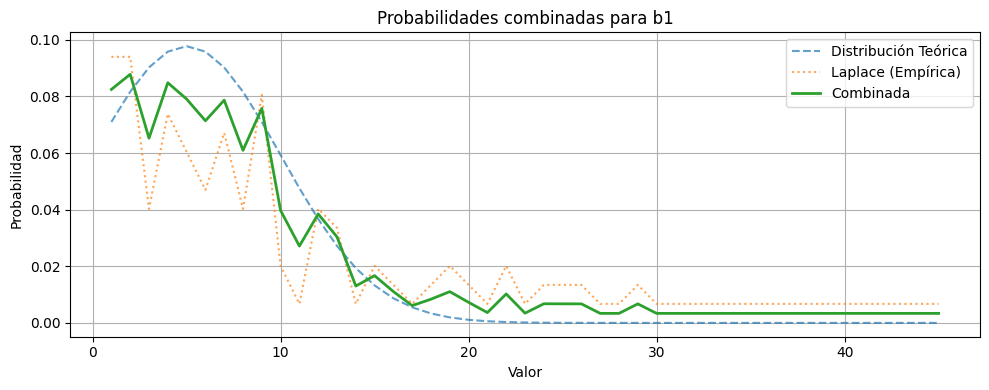

🎯 Siguientes valores más probables para b1:
  2: 0.0878
  4: 0.0848
  1: 0.0825
  5: 0.0791
  7: 0.0787
  9: 0.0758
  6: 0.0714
  3: 0.0652
  8: 0.0610
  10: 0.0397


In [24]:
b1_vals = next_gen_analyze("b1", body_size=104)

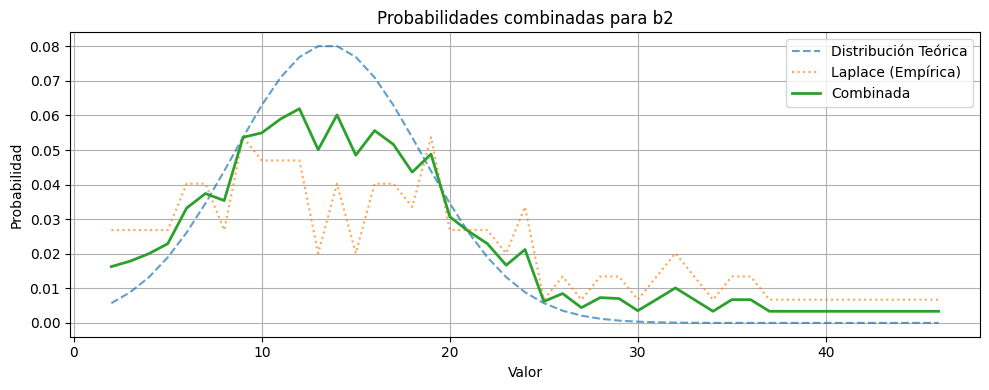

🎯 Siguientes valores más probables para b2:
  12: 0.0619
  14: 0.0602
  11: 0.0590
  16: 0.0556
  10: 0.0550
  9: 0.0537
  17: 0.0516
  13: 0.0501
  19: 0.0488
  15: 0.0485


In [25]:
b2_vals = next_gen_analyze("b2", body_size=104)

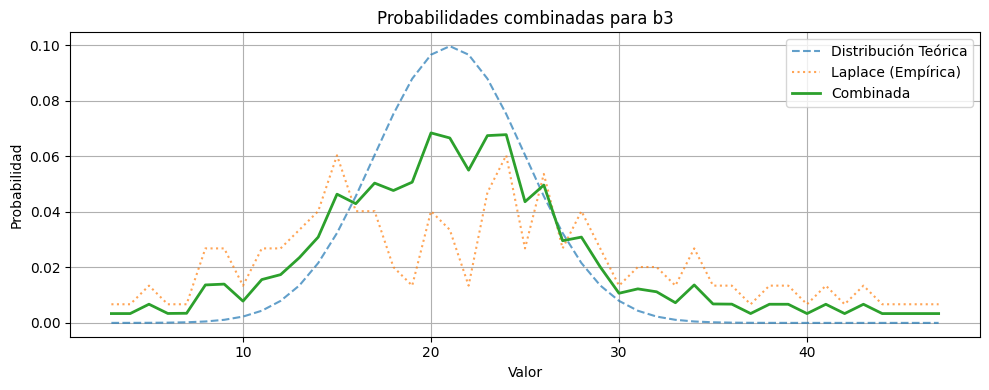

🎯 Siguientes valores más probables para b3:
  20: 0.0685
  24: 0.0678
  23: 0.0675
  21: 0.0666
  22: 0.0550
  19: 0.0507
  17: 0.0504
  26: 0.0497
  18: 0.0477
  15: 0.0464


In [26]:
b3_vals = next_gen_analyze("b3", body_size=104)

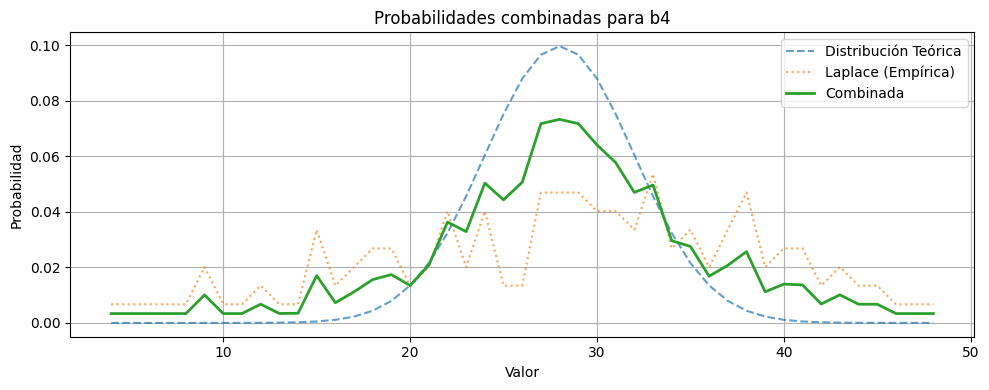

🎯 Siguientes valores más probables para b4:
  28: 0.0734
  27: 0.0718
  29: 0.0718
  30: 0.0641
  31: 0.0578
  26: 0.0507
  24: 0.0504
  33: 0.0497
  32: 0.0470
  25: 0.0444


In [27]:
b4_vals = next_gen_analyze("b4", body_size=104)

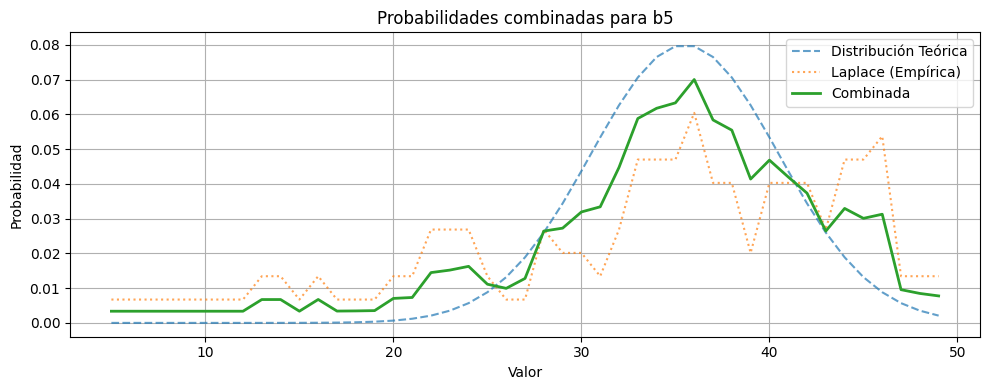

🎯 Siguientes valores más probables para b5:
  36: 0.0700
  35: 0.0633
  34: 0.0617
  33: 0.0588
  37: 0.0584
  38: 0.0554
  40: 0.0468
  32: 0.0447
  41: 0.0420
  39: 0.0414


In [28]:
b5_vals = next_gen_analyze("b5", body_size=104)

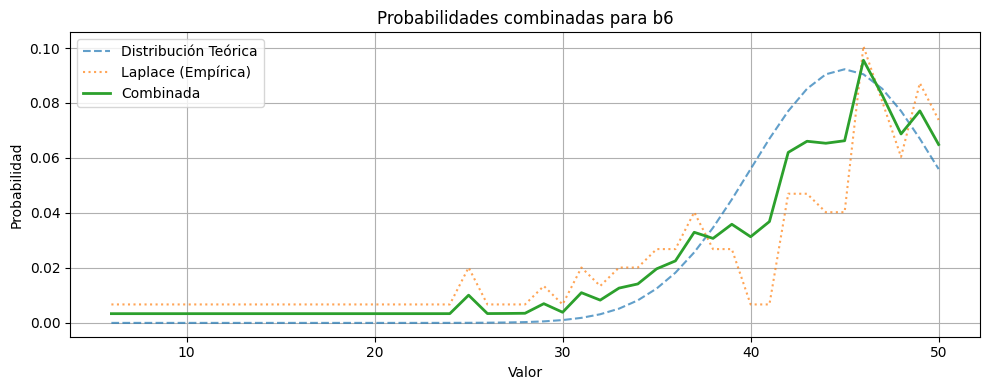

🎯 Siguientes valores más probables para b6:
  46: 0.0956
  47: 0.0829
  49: 0.0771
  48: 0.0687
  45: 0.0663
  43: 0.0661
  44: 0.0654
  50: 0.0649
  42: 0.0620
  41: 0.0369


In [29]:
b6_vals = next_gen_analyze("b6", body_size=104)